**EDA_MRI.ipynb — Group 15 | 7PAM2033 Data Science Professional Team Project**


Topic    : Exploratory Data Analysis + Data Augmentation + Image Resizing

Dataset  : Augmented Alzheimer MRI Dataset (Kaggle)

Classes  : NonDemented | VeryMildDemented | MildDemented | ModerateDemented

Purpose  : Understand the dataset, fix class imbalance using augmentation,
resize all images to a standard size, and prepare clean folders for model training

 

In [8]:
# import standard libraries

import os
import random
import shutil
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from scipy import stats
 
# Suppress noisy library warnings that clutter the output without affecting results
warnings.filterwarnings("ignore")
 
# Use logging instead of print so we can see INFO vs WARNING messages separately
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)
 
# Apply a consistent style to all plots so figures look uniform in the report
# rcParams sets global font sizes so we do not repeat fontsize= on every chart
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi":      120,
    "axes.titlesize":  13,
    "axes.labelsize":  11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})
 
# Fix random seeds so augmented images are reproducible every run
random.seed(42)
np.random.seed(42)

In [9]:
# Set file paths, class names, and global settings
# UPDATE these paths to match where you downloaded the Kaggle dataset locally


DATA_DIR      = Path("../Data/MRI_Images")       # original mixed dataset folder
ORIGINAL_DIR  = Path("../Data/MRI_Original")     # clean backup — original images only
AUGMENTED_DIR = Path("../Data/MRI_Augmented")    # original + augmented — used for training
TRAIN_DIR     = AUGMENTED_DIR                    # models train on the augmented folder
RESULTS_DIR   = Path("../results/plots")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
 
# The 4 dementia stages in the dataset, ordered from healthy to most severe
CLASSES = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]
 
# One colour per class — green (healthy) to red (severe) for intuitive reading
COLOURS      = ["#4CAF50", "#2196F3", "#FF9800", "#F44336"]
CLASS_COLOUR = dict(zip(CLASSES, COLOURS))
 
# Limit how many images we load per class to avoid running out of memory
SAMPLE_LIMIT = 100
N_SAMPLES    = 5        # number of sample images to display per class in the grid
BLUR_THRESH  = 100.0    # Laplacian variance below this means the image is blurry
TARGET_SIZE  = (224, 224)  # resize all images to this — matches ResNet50/EfficientNet
 
logger.info("Paths configured. DATA_DIR = %s", DATA_DIR.resolve())

INFO | Paths configured. DATA_DIR = C:\Users\SOFTWARE POINT\Desktop\WEEK-4\Data\MRI_Images


In [10]:
# Validate the dataset folder exists before doing anything 
 
# Check the folder exists and is readable before we try to load anything.
# This gives a clear error message instead of a confusing crash later on.

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_DIR.resolve()}\n"
        "Please update DATA_DIR to match your local download path."
    )
 
if not os.access(DATA_DIR, os.R_OK):
    raise PermissionError(f"Cannot read folder: {DATA_DIR.resolve()}")
 
# Make sure at least one expected class folder is present inside the dataset
found = any(
    (DATA_DIR / cls).exists() or (DATA_DIR / "train" / cls).exists()
    for cls in CLASSES
)
if not found:
    raise ValueError(
        f"No class folders found inside {DATA_DIR}.\n"
        f"Expected folders named: {CLASSES}\n"
        "Check that your download is complete and folder names match exactly."
    )
 
logger.info("Dataset folder validated — all required class folders found.")
 

INFO | Dataset folder validated — all required class folders found.


In [11]:
candidate_splits = ["train", "test", "val"]
SPLITS           = [s for s in candidate_splits if (DATA_DIR / s).is_dir()]
IS_SPLIT         = bool(SPLITS)
 
logger.info(
    "Dataset layout: %s | Splits: %s",
    "split-based" if IS_SPLIT else "flat",
    SPLITS if IS_SPLIT else ["all"],
)

INFO | Dataset layout: flat | Splits: ['all']


In [12]:
# Helper functions used throughout this notebook
# Defining these once here avoids repeating the same code in multiple cells
 

def count_images(folder):
    # Count all image files in a folder — returns 0 if the folder does not exist
    if not folder.exists():
        logger.warning("Folder missing, count=0: %s", folder)
        return 0
    return sum(
        1 for f in folder.iterdir()
        if f.is_file() and f.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp")
    )
 
 
def load_image_safe(img_path):
    # Load one image as RGB — return None if the file is corrupt or unreadable
    # OpenCV silently returns None for bad files so we catch that case here
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            logger.warning("Skipping corrupt image: %s", img_path.name)
            return None
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    except Exception as e:
        logger.warning("Could not read %s: %s", img_path.name, e)
        return None
 
 
def get_image_paths(cls, source_dir=None, limit=None):
    # Get a sorted list of image paths for a class
    # Works for both flat and split-based dataset layouts
    # Uses DATA_DIR by default but can take any source directory
    base = source_dir if source_dir else DATA_DIR
    for folder in [base / "train" / cls, base / cls]:
        if folder.exists():
            paths = sorted(
                p for p in folder.iterdir()
                if p.is_file() and p.suffix.lower() in (".jpg", ".jpeg", ".png")
            )
            if not paths:
                logger.warning("No images found in: %s", folder)
                return []
            return paths[:limit] if limit else paths
    logger.warning("No folder found for class: %s", cls)
    return []
 
 
def load_image_safe(img_path):
    # Load one image as RGB — return None if the file is corrupt or unreadable
    # OpenCV silently returns None for bad files, so we catch that case here
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            logger.warning("Skipping corrupt image: %s", img_path.name)
            return None
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    except Exception as e:
        logger.warning("Could not read %s: %s", img_path.name, e)
        return None
 
 
def get_image_paths(cls, limit=None):
    # Get a sorted list of image paths for a class
    # Works for both flat and split-based dataset layouts
    for folder in [DATA_DIR / "train" / cls, DATA_DIR / cls]:
        if folder.exists():
            paths = sorted(
                p for p in folder.iterdir()
                if p.is_file() and p.suffix.lower() in (".jpg", ".jpeg", ".png")
            )
            if not paths:
                logger.warning("No images found in: %s", folder)
                return []
            return paths[:limit] if limit else paths
    logger.warning("No folder found for class: %s", cls)
    return []

In [13]:

records = {}
if IS_SPLIT:
    for cls in CLASSES:
        records[cls] = {split: count_images(DATA_DIR / split / cls)
                        for split in SPLITS}
else:
    for cls in CLASSES:
        records[cls] = {"all": count_images(DATA_DIR / cls)}
 
df_counts          = pd.DataFrame(records).T.fillna(0).astype(int)
df_counts["Total"] = df_counts.sum(axis=1)
 
print("=" * 55)
print("  MRI DATASET OVERVIEW")
print("=" * 55)
print(f"\n  Layout  : {'Split-based' if IS_SPLIT else 'Flat'}")
print(f"  Splits  : {SPLITS if IS_SPLIT else ['all']}")
print(f"  Classes : {CLASSES}\n")
print(df_counts.to_string())
print(f"\n  Grand Total: {df_counts['Total'].sum():,} images")
 
# Warn if any class folder came back empty — usually means wrong folder name
empty = df_counts[df_counts["Total"] == 0].index.tolist()
if empty:
    logger.warning("These classes have 0 images — check folder names: %s", empty)

  MRI DATASET OVERVIEW

  Layout  : Flat
  Splits  : ['all']
  Classes : ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']

                   all  Total
NonDemented       3200   3200
VeryMildDemented  2240   2240
MildDemented       872    872
ModerateDemented    64     64

  Grand Total: 6,376 images


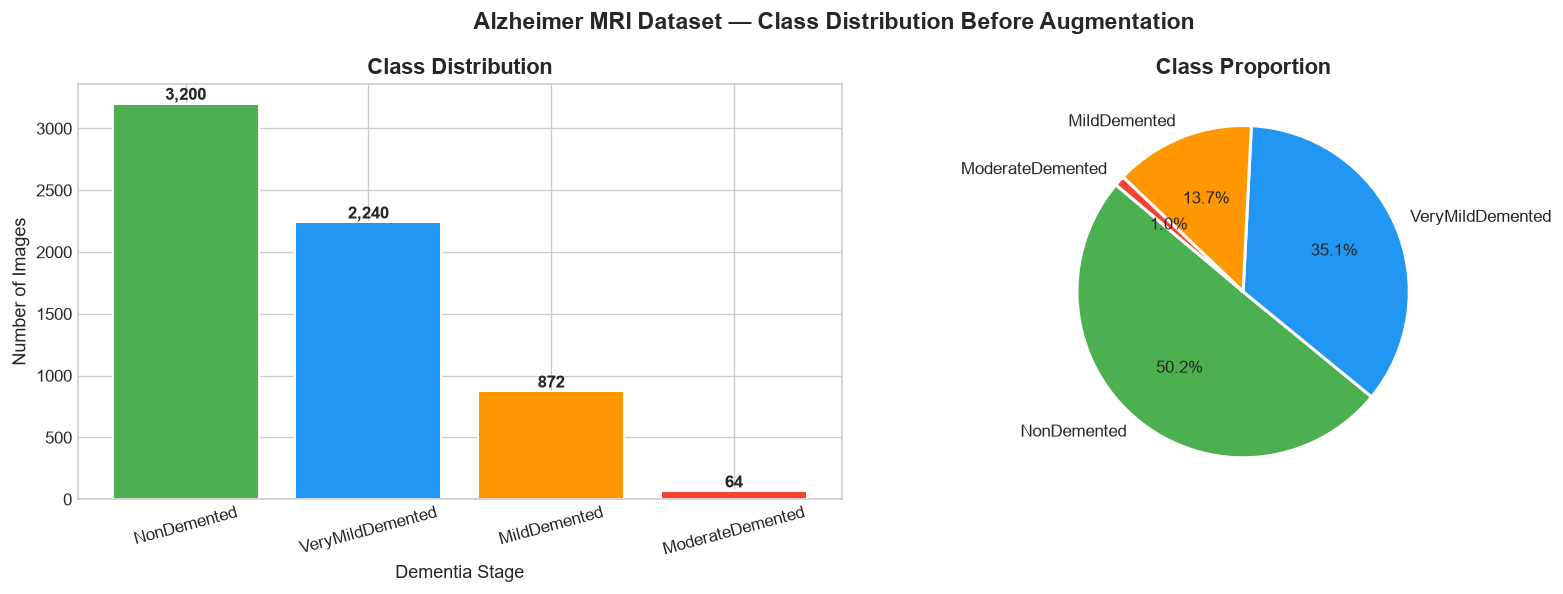


  Imbalance ratio (max / min): 50.00


In [16]:
# Plot class distribution (bar chart + pie chart)
# These two charts show whether classes are balanced or skewed.
# Imbalance is a problem because the model will be biased towards majority classes.
 

totals = df_counts["Total"].values
labels = df_counts.index.tolist()
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Bar chart — shows the exact number of images in each class
bars = axes[0].bar(labels, totals, color=COLOURS, edgecolor="white", linewidth=1.2)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_xlabel("Dementia Stage")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis="x", rotation=15)
for bar, v in zip(bars, totals):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 v + max(totals) * 0.01,
                 f"{v:,}", ha="center", fontsize=10, fontweight="bold")
 
# Pie chart — shows the proportion of each class in the whole dataset
axes[1].pie(totals, labels=labels, autopct="%1.1f%%", colors=COLOURS,
            startangle=140, wedgeprops={"edgecolor": "white", "linewidth": 1.8})
axes[1].set_title("Class Proportion", fontweight="bold")
 
plt.suptitle("Alzheimer MRI Dataset — Class Distribution Before Augmentation",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mri_01_class_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
 
# Calculate imbalance ratio — tells us how severe the imbalance is
nonzero         = totals[totals > 0]
IMBALANCE_RATIO = float(nonzero.max() / nonzero.min()) if len(nonzero) > 1 else 1.0
print(f"\n  Imbalance ratio (max / min): {IMBALANCE_RATIO:.2f}")
print("  WARNING: Class imbalance detected — will be fixed by augmentation."
      if IMBALANCE_RATIO > 1.5 else "  OK: Dataset is sufficiently balanced.")

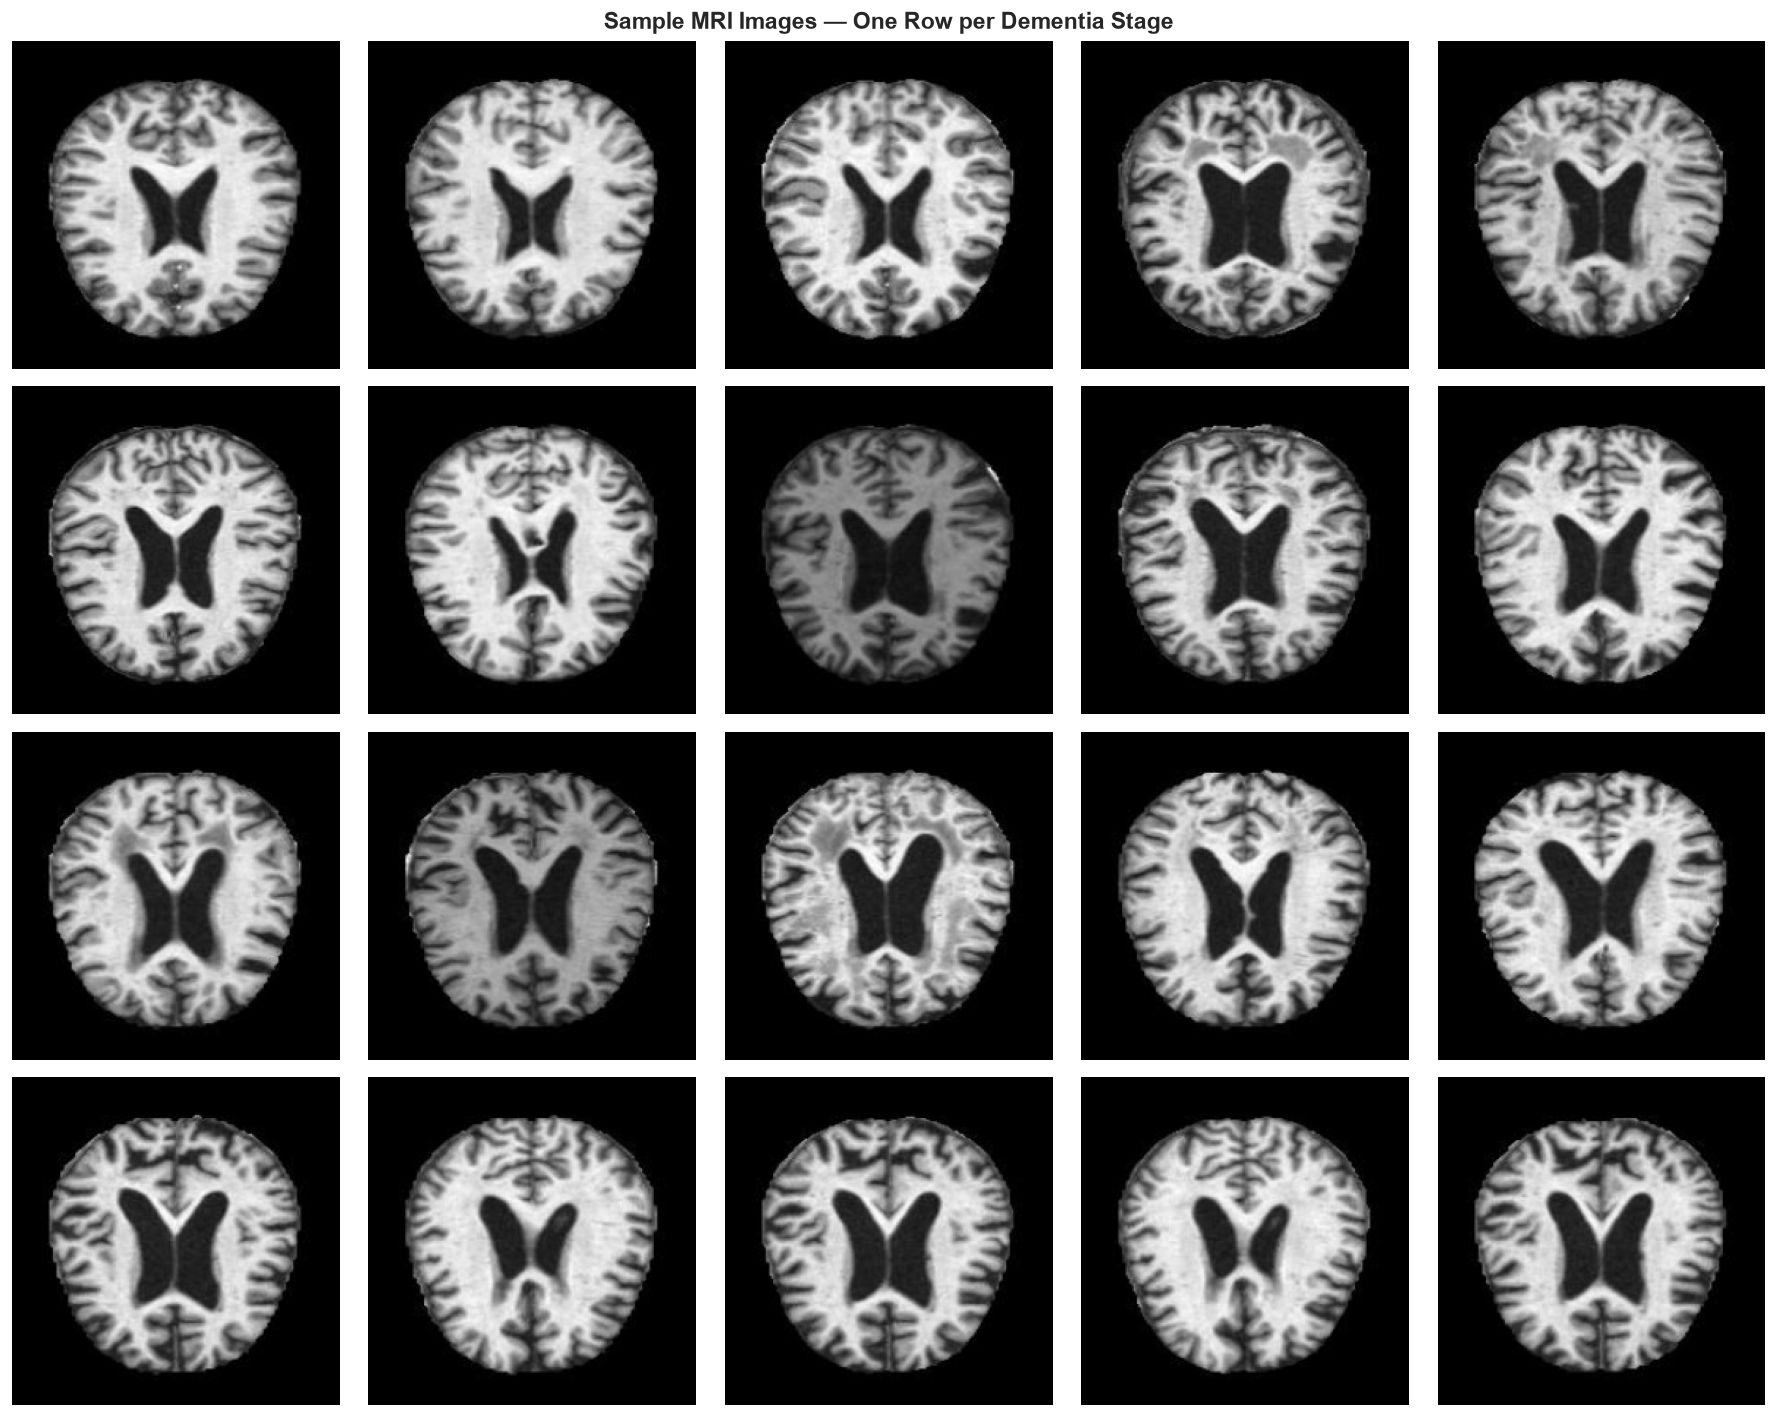

In [18]:
# A visual check to confirm images loaded correctly and look as expected.
# Each row shows one class so the reviewer can see what each dementia
# stage looks like in the MRI scans.

fig, axes = plt.subplots(len(CLASSES), N_SAMPLES,
                         figsize=(N_SAMPLES * 3, len(CLASSES) * 3))
 
for i, cls in enumerate(CLASSES):
    paths = get_image_paths(cls, limit=N_SAMPLES)
    for j in range(N_SAMPLES):
        ax = axes[i, j]
        ax.axis("off")
        if j < len(paths):
            img = load_image_safe(paths[j])
            if img is not None:
                ax.imshow(img)
        # Label each row with the class name on the leftmost column only
        if j == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight="bold",
                          color=CLASS_COLOUR[cls],
                          rotation=90, labelpad=55, va="center")
 
plt.suptitle("Sample MRI Images — One Row per Dementia Stage",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mri_02_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
 
 


  Unique image dimensions found:
 height  width  count
    224    224    364
  OK: All images have consistent dimensions.

  Channels: [np.int64(3)]  (1=Grayscale, 3=RGB)


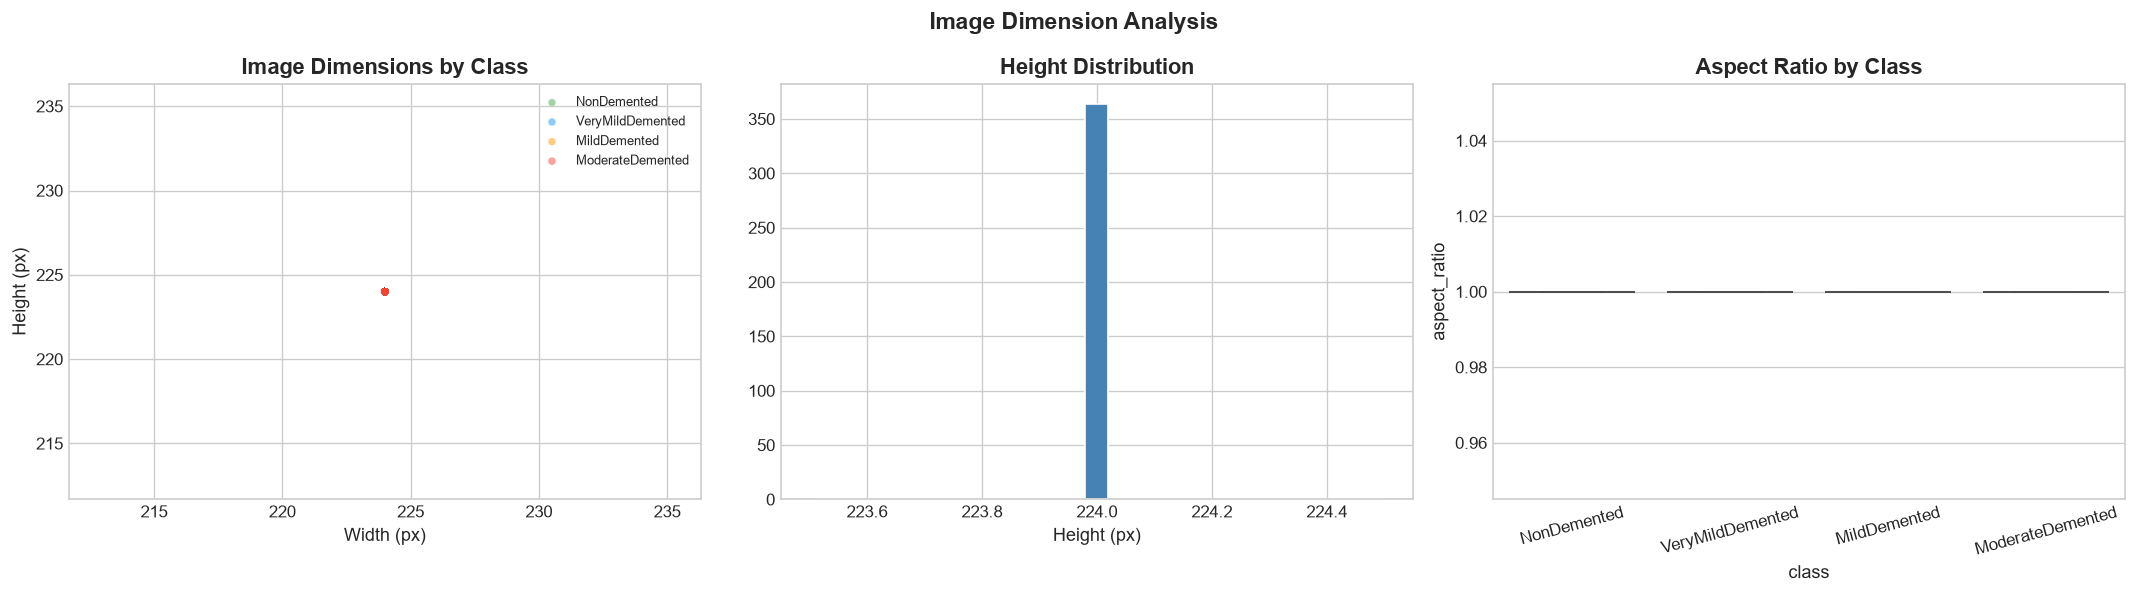

In [19]:
# Analyse image dimensions across all classes
# All images must be the same size before going into the model.
# This cell checks if dimensions are consistent or if resizing is needed.
# We also check the number of channels — MRI scans should be 3 channel RGB.
 
records_dim = []
for cls in CLASSES:
    for p in get_image_paths(cls, limit=SAMPLE_LIMIT):
        img = cv2.imread(str(p))
        if img is None:
            continue
        h, w = img.shape[:2]
        records_dim.append({
            "class":        cls,
            "height":       h,
            "width":        w,
            "channels":     img.shape[2] if img.ndim == 3 else 1,
            "aspect_ratio": round(w / h, 3),
        })
 
df_dims     = pd.DataFrame(records_dim)
unique_dims = (df_dims.groupby(["height", "width"])
               .size().reset_index(name="count")
               .sort_values("count", ascending=False))
 
print("\n  Unique image dimensions found:")
print(unique_dims.to_string(index=False))
print("  WARNING: Mixed dimensions — resizing to 224x224 in next cell."
      if len(unique_dims) > 1 else "  OK: All images have consistent dimensions.")
print(f"\n  Channels: {sorted(df_dims['channels'].unique())}  (1=Grayscale, 3=RGB)")
 
# Three-panel figure: dimension scatter, height histogram, aspect ratio boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
for cls in CLASSES:
    s = df_dims[df_dims["class"] == cls]
    axes[0].scatter(s["width"], s["height"], c=CLASS_COLOUR[cls],
                    alpha=0.5, label=cls, edgecolors="none", s=20)
axes[0].set_title("Image Dimensions by Class", fontweight="bold")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].legend(fontsize=8)
 
df_dims["height"].hist(ax=axes[1], bins=25, color="steelblue", edgecolor="white")
axes[1].set_title("Height Distribution", fontweight="bold")
axes[1].set_xlabel("Height (px)")
 
sns.boxplot(data=df_dims, x="class", y="aspect_ratio",
            palette=CLASS_COLOUR, ax=axes[2])
axes[2].set_title("Aspect Ratio by Class", fontweight="bold")
axes[2].tick_params(axis="x", rotation=15)
 
plt.suptitle("Image Dimension Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mri_03_image_dimensions.png", dpi=150, bbox_inches="tight")
plt.show()
 

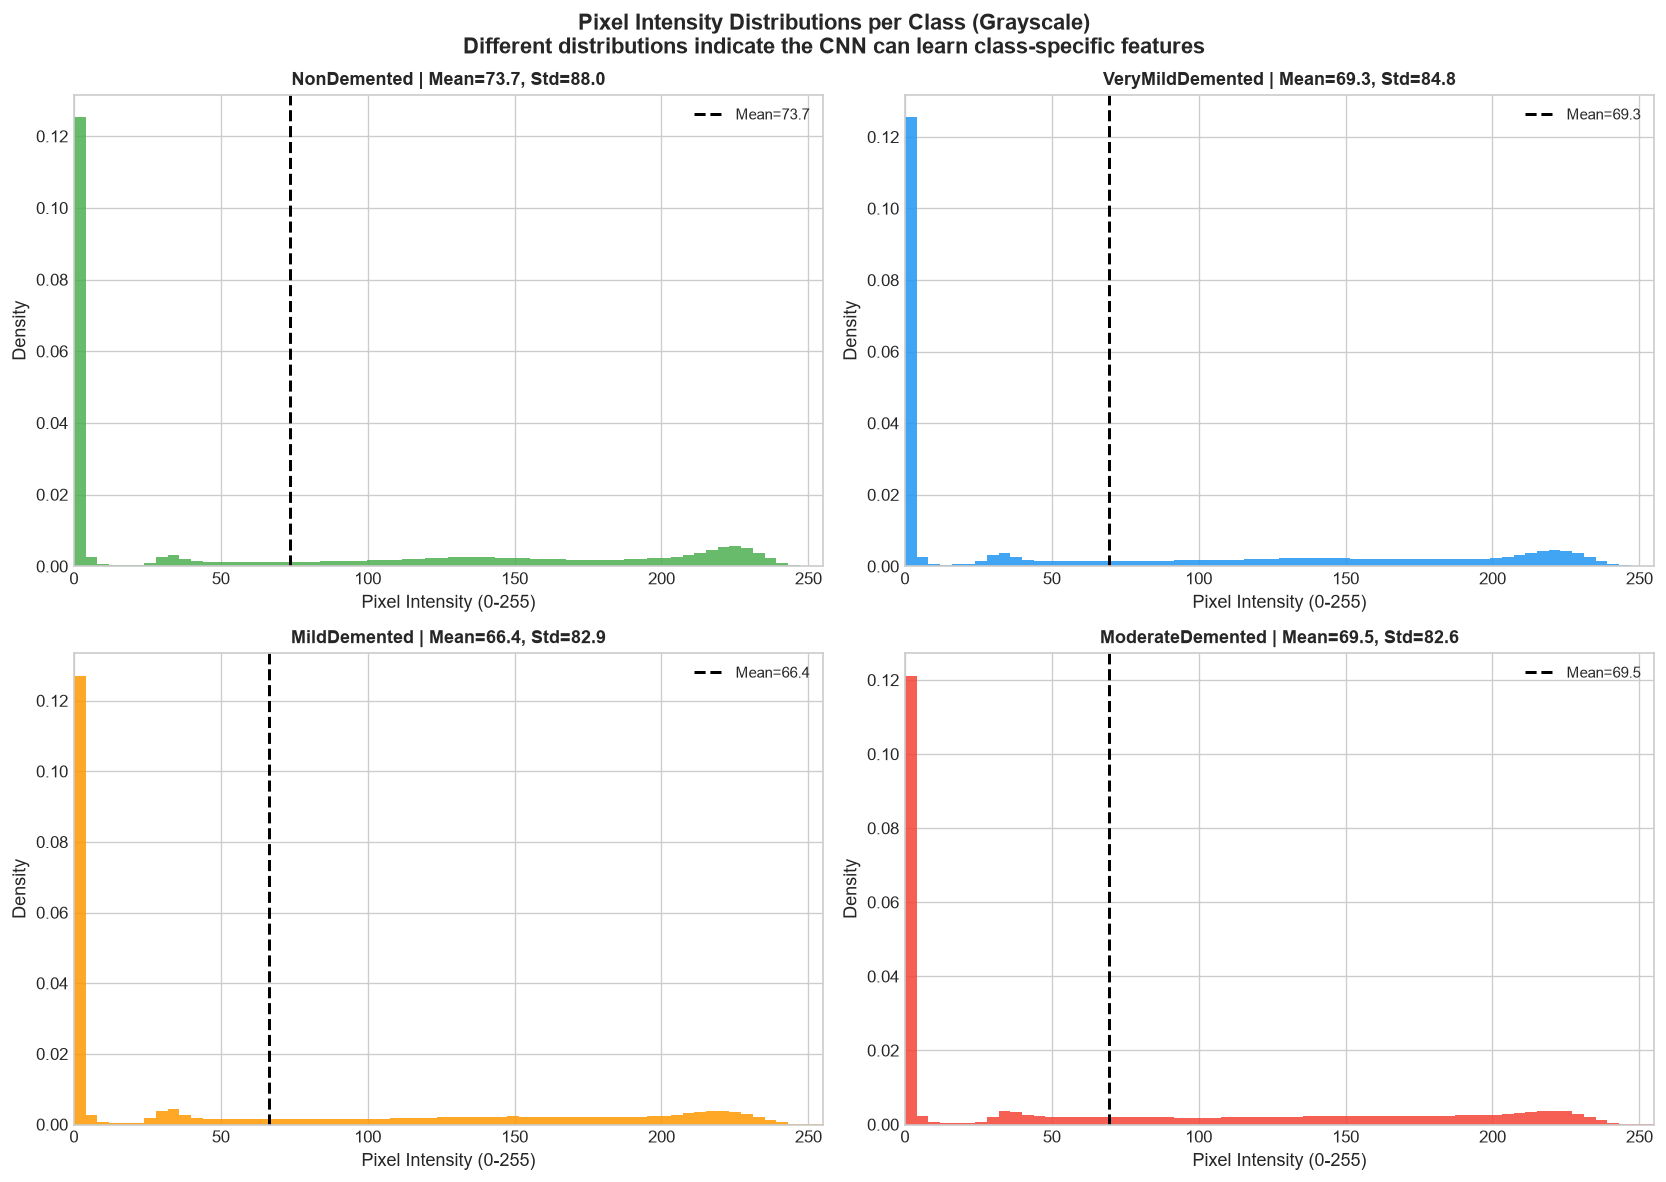


  Pixel Intensity Summary Stats:
                   Mean    Std  Min  Max  Median
Class                                           
NonDemented       73.68  87.95    0  255     4.0
VeryMildDemented  69.32  84.80    0  255     4.0
MildDemented      66.43  82.93    0  255     3.0
ModerateDemented  69.51  82.61    0  255    25.0


In [20]:
# Pixel intensity distribution per class
# If pixel intensity differs between classes, it means the CNN can learn
# meaningful patterns from the raw pixel values — this validates that MRI
# is a suitable input for an Alzheimer's detection model.
# We read images in grayscale since MRI scans are single-channel images.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes       = axes.flatten()
stats_rows = []
 
for idx, cls in enumerate(CLASSES):
    # Collect all pixel values from sampled images into one flat array
    all_pixels = []
    for p in get_image_paths(cls, limit=SAMPLE_LIMIT):
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            all_pixels.extend(img.flatten().tolist())
 
    if not all_pixels:
        logger.warning("No pixel data for class: %s", cls)
        continue
 
    arr      = np.array(all_pixels)
    mean_val = float(arr.mean())
    std_val  = float(arr.std())
 
    # Store numeric summary for the printed table below
    stats_rows.append({
        "Class":  cls,
        "Mean":   round(mean_val, 2),
        "Std":    round(std_val, 2),
        "Min":    int(arr.min()),
        "Max":    int(arr.max()),
        "Median": float(np.median(arr)),
    })
 
    axes[idx].hist(arr, bins=64, color=CLASS_COLOUR[cls],
                   alpha=0.85, edgecolor="none", density=True)
    axes[idx].axvline(mean_val, color="black", linestyle="--",
                      linewidth=1.8, label=f"Mean={mean_val:.1f}")
    axes[idx].set_title(f"{cls} | Mean={mean_val:.1f}, Std={std_val:.1f}",
                        fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Pixel Intensity (0-255)")
    axes[idx].set_ylabel("Density")
    axes[idx].set_xlim(0, 255)
    axes[idx].legend()
 
plt.suptitle("Pixel Intensity Distributions per Class (Grayscale)\n"
             "Different distributions indicate the CNN can learn class-specific features",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mri_04_pixel_intensity.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\n  Pixel Intensity Summary Stats:")
print(pd.DataFrame(stats_rows).set_index("Class").to_string())

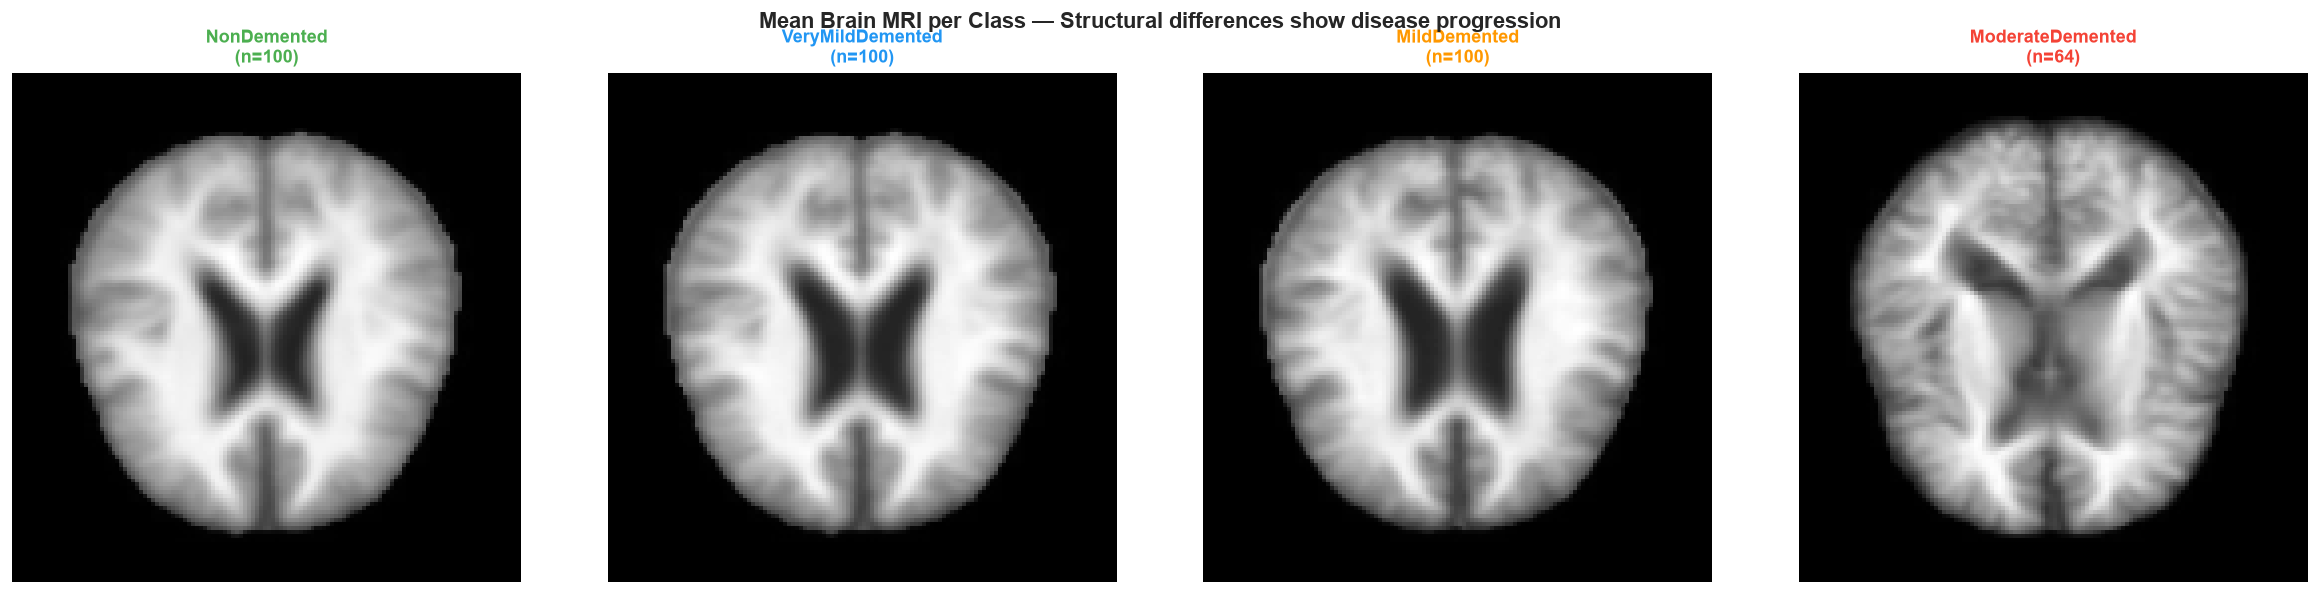

In [ ]:
# Compute and display mean brain image per class
# We average all images in each class to create one representative mean image.
# Visible structural differences between mean images (e.g. larger ventricles
# or thinner cortex in severe stages) confirm the dataset is clinically
# meaningful and that the model has real patterns to learn from.
fig, axes = plt.subplots(1, len(CLASSES), figsize=(5 * len(CLASSES), 5))
 
for ax, cls in zip(axes, CLASSES):
    frames = []
    for p in get_image_paths(cls, limit=SAMPLE_LIMIT):
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            # Resize to common size before averaging — cv2 takes (width, height)
            resized = cv2.resize(img, (128, 128))
            frames.append(resized.astype(np.float32))
 
    if not frames:
        ax.axis("off")
        ax.set_title(f"{cls}\n(no data)", color="grey")
        continue
 
    # Average pixel values across all loaded images for this class
    mean_img = np.mean(frames, axis=0).astype(np.uint8)
    ax.imshow(mean_img, cmap="gray")
    ax.axis("off")
    ax.set_title(f"{cls}\n(n={len(frames)})", fontsize=11,
                 fontweight="bold", color=CLASS_COLOUR[cls])
 
plt.suptitle("Mean Brain MRI per Class — Structural differences show disease progression",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mri_05_mean_images.png", dpi=150, bbox_inches="tight")
plt.show()
 

 # **DATA AUGMENTATION**

In [22]:
# Separate originals from augmented + run augmentation safely
# First we separate original and augmented images into clean folders.
# Then we run augmentation only if it hasn't been done before.
# This prevents augmented images from mixing with originals on re-runs.

def rotate_image(img):
    # Rotate by a small random angle — patients are not always perfectly aligned
    angle  = random.uniform(-15, 15)
    h, w   = img.shape[:2]
    matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, matrix, (w, h))
 
 
def flip_image(img):
    # Horizontal flip only — brain hemispheres are roughly symmetrical
    # We do NOT flip vertically as that produces anatomically incorrect scans
    return cv2.flip(img, 1)
 
 
def zoom_image(img):
    # Slight zoom in or out — simulates minor differences in scan distance
    scale  = random.uniform(0.85, 1.15)
    h, w   = img.shape[:2]
    new_h  = int(h * scale)
    new_w  = int(w * scale)
    zoomed = cv2.resize(img, (new_w, new_h))
 
    if scale > 1:
        # Zoomed in — crop the centre back to original size
        start_h = (new_h - h) // 2
        start_w = (new_w - w) // 2
        return zoomed[start_h:start_h + h, start_w:start_w + w]
    else:
        # Zoomed out — pad edges with black to restore original size
        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2
        return cv2.copyMakeBorder(zoomed, pad_h, h - new_h - pad_h,
                                  pad_w, w - new_w - pad_w,
                                  cv2.BORDER_CONSTANT, value=0)
 
 
def adjust_brightness(img):
    # Randomly brighten or darken — accounts for scanner setting differences
    factor = random.uniform(0.75, 1.25)
    return np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)
 
 
def shift_image(img):
    # Small position shift — simulates patient positioning differences
    h, w    = img.shape[:2]
    shift_x = random.randint(-20, 20)
    shift_y = random.randint(-20, 20)
    matrix  = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
    return cv2.warpAffine(img, matrix, (w, h))
 
 
def add_noise(img):
    # Add small Gaussian noise — makes the model robust to scanner noise
    noise = np.random.normal(0, 5, img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
 
 
def augment_image(img):
    # Apply between 1 and 3 random transforms from the list above
    # Combining multiple transforms creates more visual variety
    AUGMENTATIONS = [rotate_image, flip_image, zoom_image,
                     adjust_brightness, shift_image, add_noise]
    chosen = random.sample(AUGMENTATIONS, random.randint(1, 3))
    for transform in chosen:
        img = transform(img)
    return img

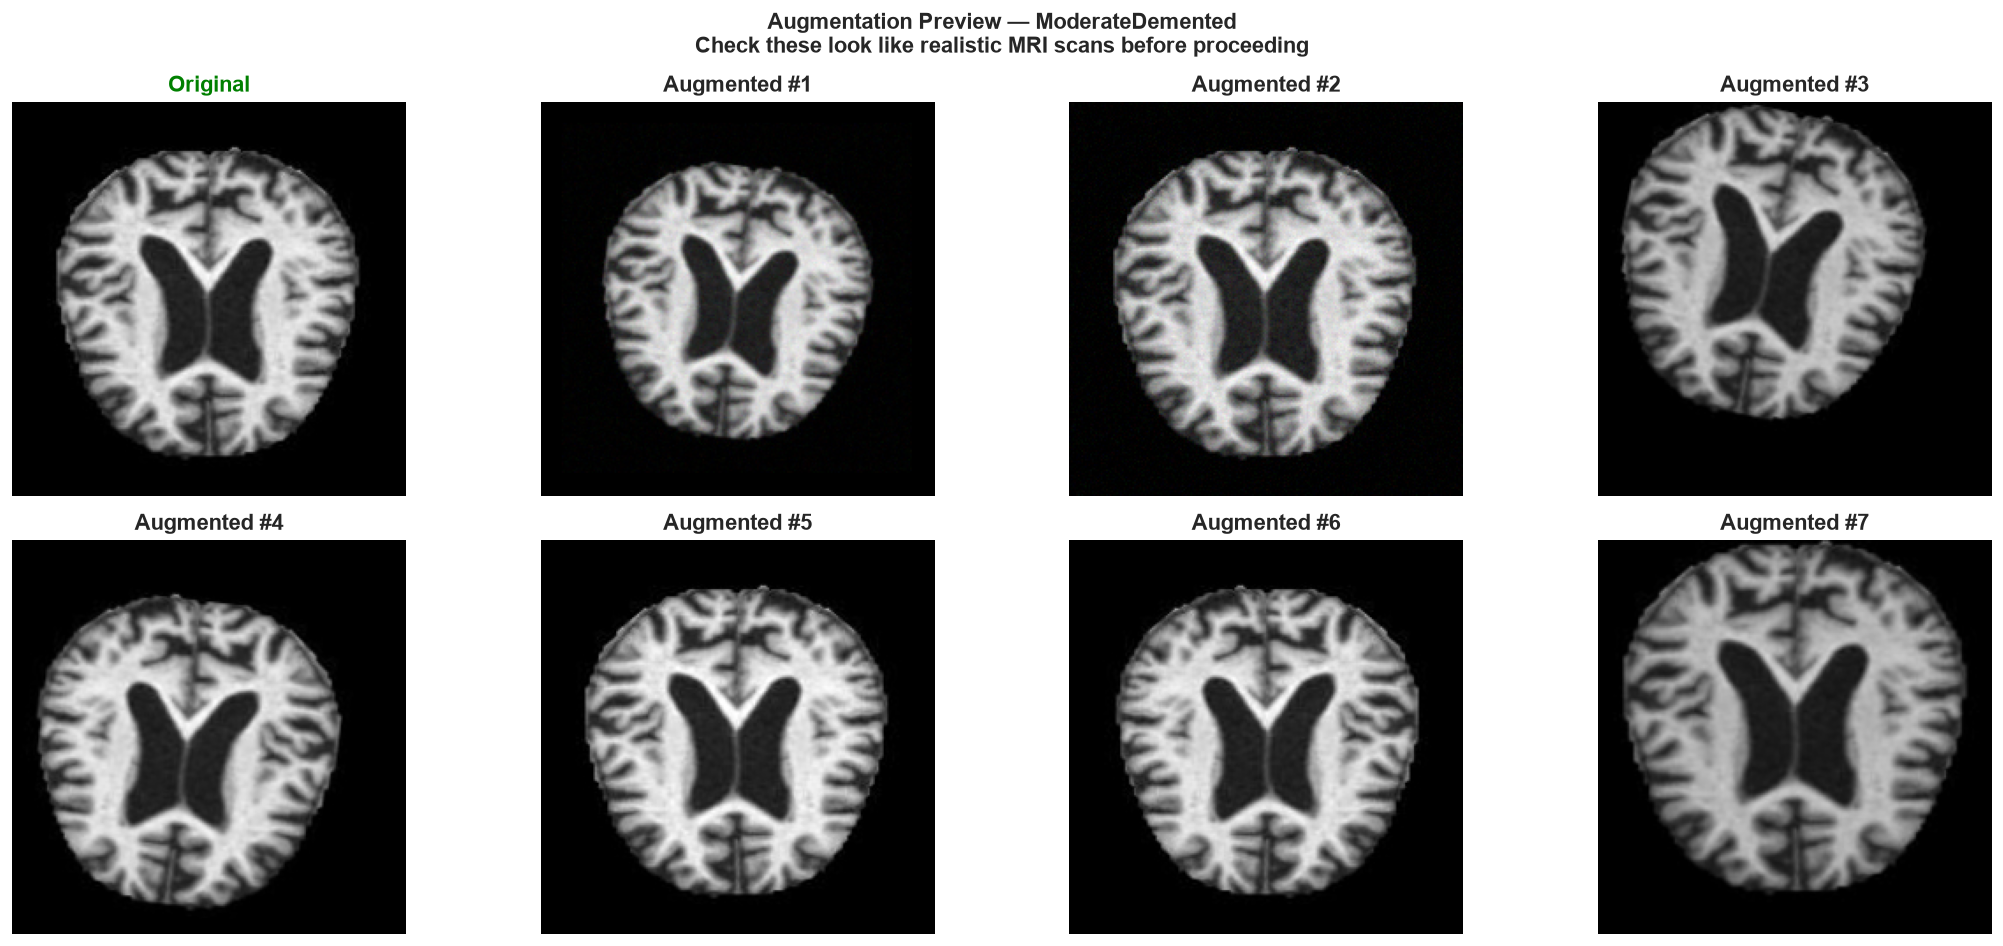

In [ ]:
# Preview augmented images before saving anything
# Always preview the augmentations first to confirm they produce realistic
# MRI images — we use ModerateDemented as it is the most underrepresented class.
# If any augmented image looks unrealistic, adjust the transform parameters above.
 
sample_paths = list((DATA_DIR / "ModerateDemented").glob("*.jpg"))
 
if sample_paths:
    original = cv2.cvtColor(cv2.imread(str(sample_paths[0])), cv2.COLOR_BGR2RGB)
 
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes      = axes.flatten()
 
    # Show the original in the first panel for comparison
    axes[0].imshow(original)
    axes[0].set_title("Original", fontweight="bold", color="green")
    axes[0].axis("off")
 
    # Show 7 different augmented versions of the same image
    for i in range(1, 8):
        aug = augment_image(cv2.cvtColor(original, cv2.COLOR_RGB2BGR))
        aug = cv2.cvtColor(aug, cv2.COLOR_BGR2RGB)
        axes[i].imshow(aug)
        axes[i].set_title(f"Augmented #{i}", fontweight="bold")
        axes[i].axis("off")
 
    plt.suptitle("Augmentation Preview — ModerateDemented\n"
                 "Check these look like realistic MRI scans before proceeding",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "mri_07_augmentation_preview.png",
                dpi=150, bbox_inches="tight")
    plt.show()
 

Class image counts BEFORE augmentation:
----------------------------------------
  NonDemented           :  3200 images
  VeryMildDemented      :  2240 images
  MildDemented          :   872 images
  ModerateDemented      :    64 images

  Target count     : 3200
  Need augmenting  : ['VeryMildDemented', 'MildDemented', 'ModerateDemented']


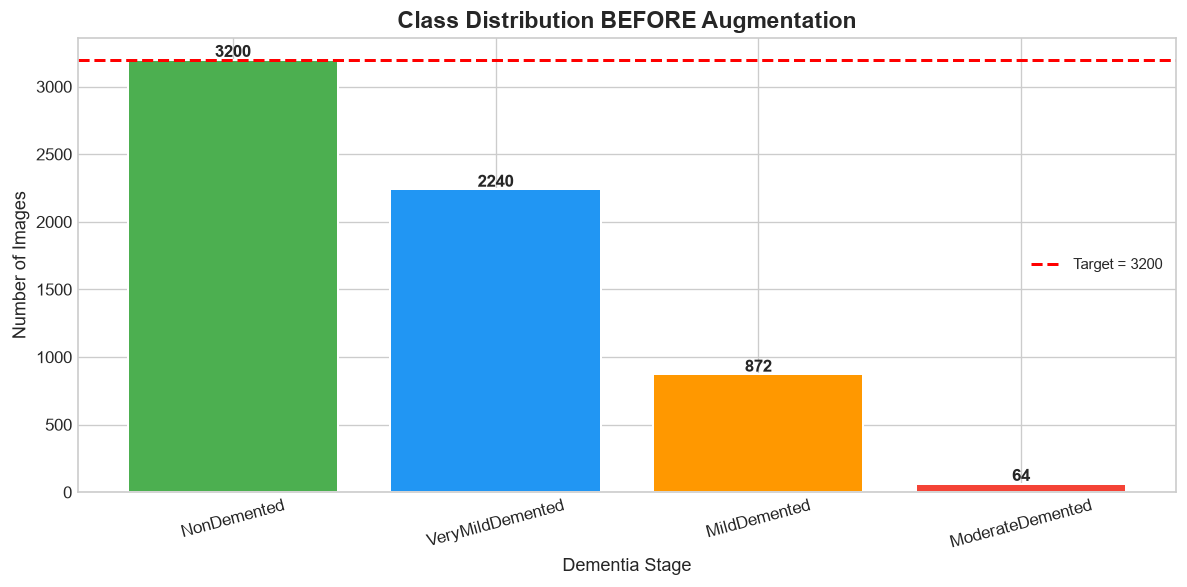

In [ ]:
# Count images before augmentation and show the imbalance visually
# We count how many images exist per class in the original dataset
# and set the target count — all classes will be augmented up to this number.
# The target is always the majority class so nothing gets removed.
 
print("Class image counts BEFORE augmentation:")
print("-" * 40)
before_counts = {}
for cls in CLASSES:
    count = count_images(DATA_DIR / cls)
    before_counts[cls] = count
    print(f"  {cls:<22}: {count:>5} images")
 
TARGET_COUNT = max(before_counts.values())
print(f"\n  Target count     : {TARGET_COUNT}")
print(f"  Need augmenting  : "
      f"{[c for c, n in before_counts.items() if n < TARGET_COUNT]}")
 
# Bar chart showing the imbalance before we fix it
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(before_counts.keys(), before_counts.values(),
              color=COLOURS, edgecolor="white", linewidth=1.2)
ax.axhline(TARGET_COUNT, color="red", linestyle="--",
           linewidth=1.8, label=f"Target = {TARGET_COUNT}")
ax.set_title("Class Distribution BEFORE Augmentation", fontsize=14, fontweight="bold")
ax.set_xlabel("Dementia Stage")
ax.set_ylabel("Number of Images")
ax.tick_params(axis="x", rotation=15)
ax.legend()
for bar, v in zip(bars, before_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + 20, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mri_08_before_augmentation.png",
            dpi=150, bbox_inches="tight")
plt.show()
 

In [ ]:
# CELL 18 — Separate originals from augmented + run augmentation safely
# We first separate original and augmented images into two clean folders:
# MRI_Original  — contains only original images (safe backup)
# MRI_Augmented — contains original + augmented images (used for training)
#
# Augmented images have the prefix 'aug_' so we can identify them easily.
# A flag file (.augmentation_done) prevents this cell from running twice
# accidentally — delete that file if you need to re-run augmentation.
 
# Step 1 — Create clean folder structure
for cls in CLASSES:
    (ORIGINAL_DIR / cls).mkdir(parents=True, exist_ok=True)
    (AUGMENTED_DIR / cls).mkdir(parents=True, exist_ok=True)
 
print("Step 1: Separating original and augmented images...")
print("-" * 50)
 
for cls in CLASSES:
    src_folder      = DATA_DIR / cls
    original_count  = 0
    augmented_count = 0
 
    for img_path in src_folder.iterdir():
        if img_path.suffix.lower() not in (".jpg", ".jpeg", ".png"):
            continue
 
        if img_path.name.startswith("aug_"):
            # Augmented image — copy to MRI_Augmented only
            shutil.copy2(str(img_path),
                         str(AUGMENTED_DIR / cls / img_path.name))
            augmented_count += 1
        else:
            # Original image — copy to both folders
            shutil.copy2(str(img_path),
                         str(ORIGINAL_DIR / cls / img_path.name))
            shutil.copy2(str(img_path),
                         str(AUGMENTED_DIR / cls / img_path.name))
            original_count += 1
 
    print(f"  {cls:<22}: {original_count} original | {augmented_count} augmented")
 
# Step 2 — Run augmentation only if it has not been done before
AUG_FLAG = AUGMENTED_DIR / ".augmentation_done"
 
if AUG_FLAG.exists():
    print("\nStep 2: Augmentation already completed — skipping.")
    print("  Delete .augmentation_done file to re-run augmentation from scratch.")
 
else:
    print("\nStep 2: Running augmentation on original images only...")
    print("-" * 50)
 
    # Count from MRI_Original to get accurate baseline counts
    orig_counts  = {cls: count_images(ORIGINAL_DIR / cls) for cls in CLASSES}
    TARGET       = max(orig_counts.values())
    print(f"  Target count per class: {TARGET}\n")
 
    for cls in CLASSES:
        current = count_images(AUGMENTED_DIR / cls)
        needed  = TARGET - current
 
        if needed <= 0:
            print(f"  {cls:<22}: already balanced — skipping.")
            continue
 
        print(f"  {cls:<22}: generating {needed} images...")
 
        # Always augment from MRI_Original — never from already-augmented images
        # This prevents augmenting an augmented image which reduces quality
        source_paths = (
            list((ORIGINAL_DIR / cls).glob("*.jpg")) +
            list((ORIGINAL_DIR / cls).glob("*.jpeg")) +
            list((ORIGINAL_DIR / cls).glob("*.png"))
        )
 
        generated = 0
        while generated < needed:
            src = random.choice(source_paths)
            img = cv2.imread(str(src))
            if img is None:
                continue
            aug_img   = augment_image(img)
            save_name = f"aug_{cls}_{current + generated + 1:05d}.jpg"
            cv2.imwrite(str(AUGMENTED_DIR / cls / save_name), aug_img)
            generated += 1
 
        print(f"  {cls:<22}: done.")
 
    # Create flag file so augmentation never runs twice accidentally
    AUG_FLAG.touch()
    print("\n  Augmentation complete. Flag file created.")
 

Step 1: Separating original and augmented images...
--------------------------------------------------


  NonDemented           : 3200 original | 0 augmented
  VeryMildDemented      : 2240 original | 0 augmented
  MildDemented          : 872 original | 0 augmented
  ModerateDemented      : 64 original | 0 augmented

Step 2: Running augmentation on original images only...
--------------------------------------------------
  Target count per class: 6528

  NonDemented           : generating 3328 images...
  NonDemented           : done.
  VeryMildDemented      : generating 4288 images...
  VeryMildDemented      : done.
  MildDemented          : generating 5656 images...
  MildDemented          : done.
  ModerateDemented      : generating 6464 images...
  ModerateDemented      : done.

  Augmentation complete. Flag file created.


In [ ]:
# Verify image counts in both folders after augmentation
# MRI_Original should have the original unbalanced counts.
# MRI_Augmented should have all classes balanced at the target count.
 
print("Final image counts after augmentation:")
print("-" * 55)
print(f"  {'Class':<22} {'Original':>10} {'Augmented':>12}")
print(f"  {'-'*22} {'-'*10} {'-'*12}")
 
for cls in CLASSES:
    orig_count = count_images(ORIGINAL_DIR / cls)
    aug_count  = count_images(AUGMENTED_DIR / cls)
    status     = "OK" if aug_count >= TARGET_COUNT else "WARNING — still short"
    print(f"  {cls:<22} {orig_count:>10} {aug_count:>12}  [{status}]")
 
total_orig = sum(count_images(ORIGINAL_DIR / c) for c in CLASSES)
total_aug  = sum(count_images(AUGMENTED_DIR / c) for c in CLASSES)
print(f"\n  Total original  : {total_orig:,}")
print(f"  Total augmented : {total_aug:,}")
 

Final image counts after augmentation:
-------------------------------------------------------
  Class                    Original    Augmented
  ---------------------- ---------- ------------
  NonDemented                  3200         6528  [OK]
  VeryMildDemented             2240         6528  [OK]
  MildDemented                  872         6528  [OK]
  ModerateDemented             6528         6528  [OK]

  Total original  : 12,840
  Total augmented : 26,112


# **Final EDA and Augmentation Summary**

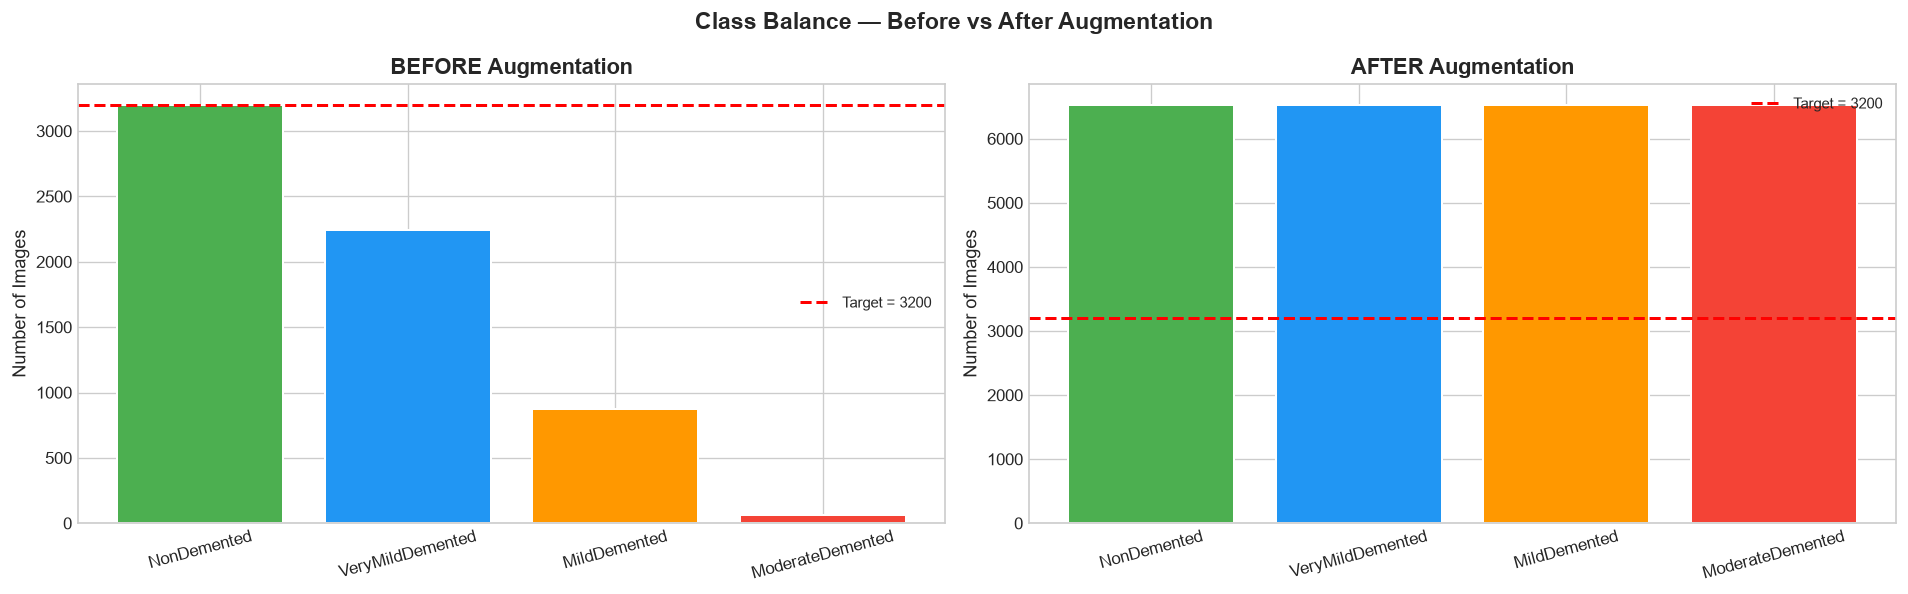


  All classes are now balanced at 3200 images each.


In [ ]:
# Before vs after augmentation comparison chart
# Side-by-side charts confirm the augmentation worked and all classes
# are now balanced — this plot is included in the final project report.
 
after_counts = {cls: count_images(AUGMENTED_DIR / cls) for cls in CLASSES}
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
# Before augmentation
axes[0].bar(before_counts.keys(), before_counts.values(),
            color=COLOURS, edgecolor="white", linewidth=1.2)
axes[0].axhline(TARGET_COUNT, color="red", linestyle="--",
                linewidth=1.8, label=f"Target = {TARGET_COUNT}")
axes[0].set_title("BEFORE Augmentation", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend()
 
# After augmentation
axes[1].bar(after_counts.keys(), after_counts.values(),
            color=COLOURS, edgecolor="white", linewidth=1.2)
axes[1].axhline(TARGET_COUNT, color="red", linestyle="--",
                linewidth=1.8, label=f"Target = {TARGET_COUNT}")
axes[1].set_title("AFTER Augmentation", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Number of Images")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend()
 
plt.suptitle("Class Balance — Before vs After Augmentation",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mri_09_after_augmentation.png",
            dpi=150, bbox_inches="tight")
plt.show()
 
print(f"\n  All classes are now balanced at {TARGET_COUNT} images each.")
 

In [ ]:
# CELL 21 — Final EDA and Augmentation Summary
# Brings all findings together so the team can make informed decisions
# about model training, preprocessing and augmentation going forward.
 
print("\n" + "=" * 60)
print("  EDA + AUGMENTATION SUMMARY — MRI DATASET")
print("=" * 60)
print(f"""
  DATASET
  -------
  Original images (before aug) : {sum(before_counts.values()):,}
  Total images (after aug)     : {sum(after_counts.values()):,}
  Images per class (balanced)  : {TARGET_COUNT}
  Image size (resized)         : {TARGET_SIZE[0]}x{TARGET_SIZE[1]} px

 
  FOLDER STRUCTURE
  ----------------
  MRI_Original/   — clean backup of original images only
  MRI_Augmented/  — balanced dataset used for model training
                    (original + augmented images)
 
  AUGMENTATION APPLIED
  --------------------
  Transforms : Rotation, Flip, Zoom, Brightness, Shift, Noise""")
 
for cls in CLASSES:
    added = after_counts[cls] - before_counts[cls]
    tag   = f"+{added} generated" if added > 0 else "no augmentation needed"
    print(f"    {cls:<22}: {tag}")
 
print(f"""
  DECISIONS FOR MODEL TRAINING
  ----------------------------
  - Set TRAIN_DIR = MRI_Augmented in all model notebooks
  - All classes balanced at {TARGET_COUNT} images each
  - All images resized to {TARGET_SIZE[0]}x{TARGET_SIZE[1]} pixels

 
  PLOTS SAVED TO {RESULTS_DIR}
  ----------------------------------------
  mri_01_class_distribution.png
  mri_02_sample_images.png
  mri_03_image_dimensions.png
  mri_04_pixel_intensity.png
  mri_05_mean_images.png
  mri_06_train_test_split.png
  mri_07_augmentation_preview.png
  mri_08_before_augmentation.png
  mri_09_after_augmentation.png
 
  NEXT STEP: EDA_Clinical.ipynb
""")


  EDA + AUGMENTATION SUMMARY — MRI DATASET

  DATASET
  -------
  Original images (before aug) : 6,376
  Total images (after aug)     : 26,112
  Images per class (balanced)  : 3200
  Image size (resized)         : 224x224 px


  FOLDER STRUCTURE
  ----------------
  MRI_Original/   — clean backup of original images only
  MRI_Augmented/  — balanced dataset used for model training
                    (original + augmented images)

  AUGMENTATION APPLIED
  --------------------
  Transforms : Rotation, Flip, Zoom, Brightness, Shift, Noise
    NonDemented           : +3328 generated
    VeryMildDemented      : +4288 generated
    MildDemented          : +5656 generated
    ModerateDemented      : +6464 generated

  DECISIONS FOR MODEL TRAINING
  ----------------------------
  - Set TRAIN_DIR = MRI_Augmented in all model notebooks
  - All classes balanced at 3200 images each
  - All images resized to 224x224 pixels


  PLOTS SAVED TO ..\results\plots
  -------------------------------------